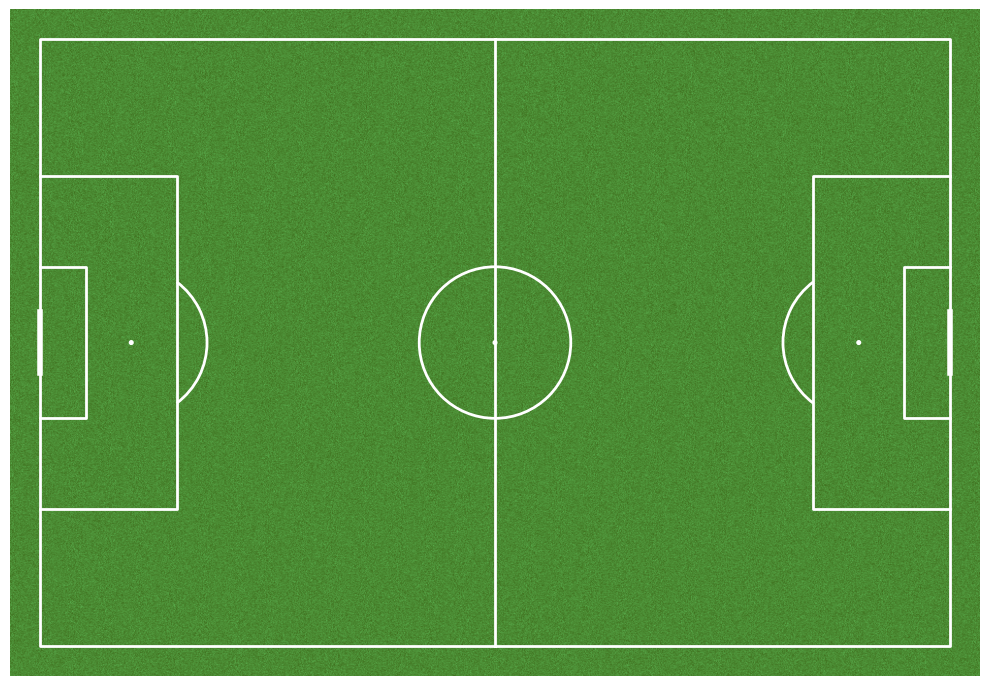

In [2]:
from statsbombpy import sb
from mplsoccer import Pitch
import matplotlib.pyplot as plt

match_id = 3895158
events = sb.events(match_id)

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))
plt.show()

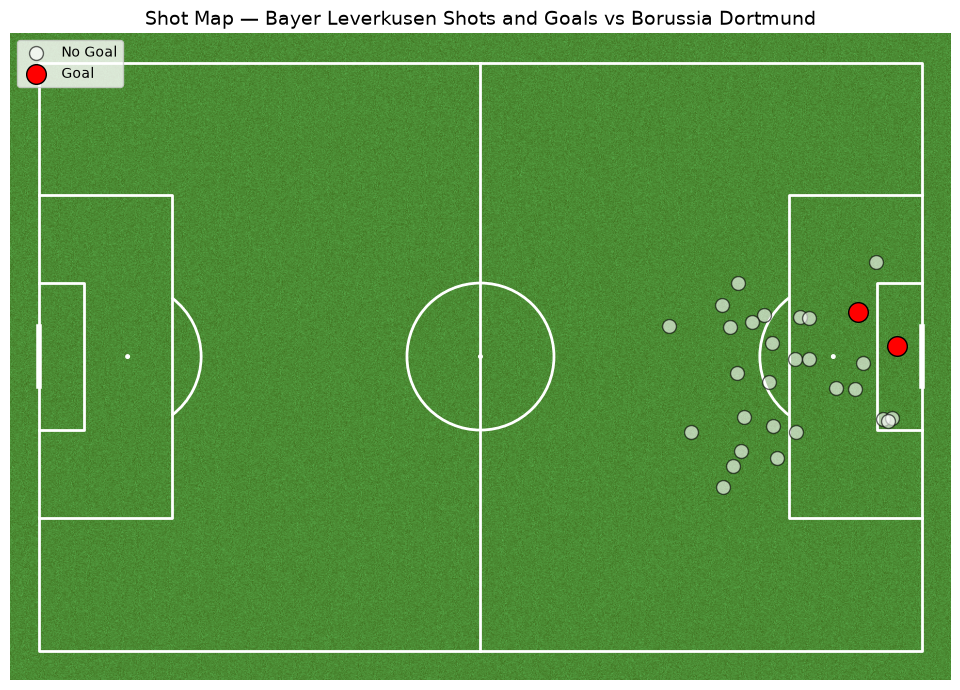

In [4]:
shots = events[events['type'] == 'Shot']

shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

# Goals in one color, everything else in another
goals = shots[shots['shot_outcome'] == 'Goal']
non_goals = shots[shots['shot_outcome'] != 'Goal']

pitch.scatter(non_goals['x'], non_goals['y'], ax=ax, color='white', edgecolors='black', s=100, alpha=0.6, label='No Goal')
pitch.scatter(goals['x'], goals['y'], ax=ax, color='red', edgecolors='black', s=200, label='Goal')

ax.legend(loc='upper left', fontsize=10)
plt.title('Shot Map — Bayer Leverkusen Shots and Goals vs Borussia Dortmund', fontsize=14)
plt.savefig('shot_map.png', dpi=150, bbox_inches='tight')
plt.show()

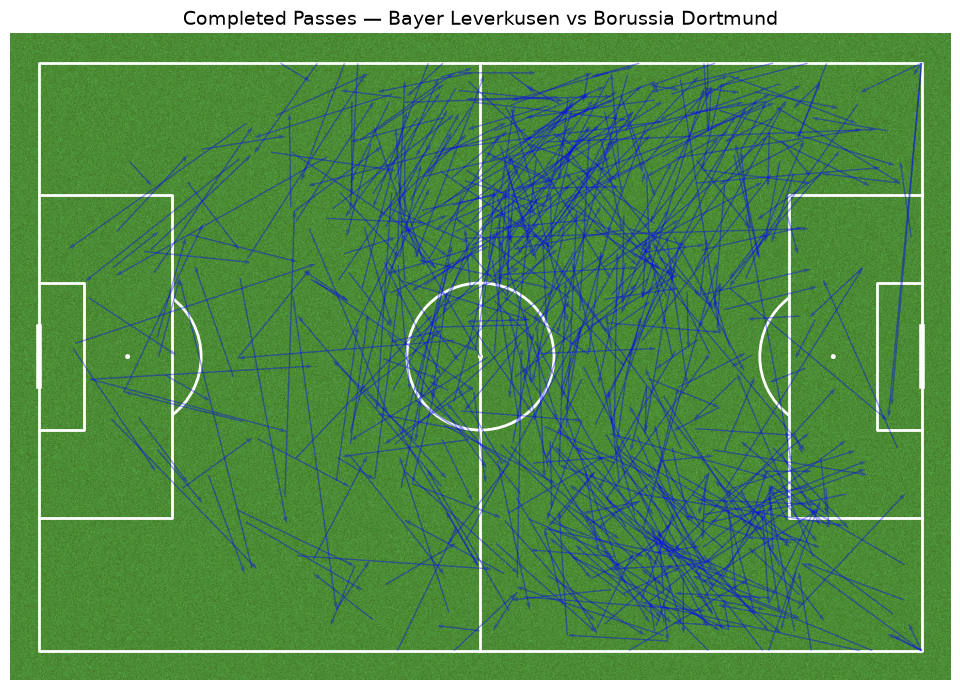

In [10]:
passes = events[(events['type'] == 'Pass') & (events['team'] == 'Bayer Leverkusen')]

passes['x'] = passes['location'].apply(lambda loc: loc[0])
passes['y'] = passes['location'].apply(lambda loc: loc[1])
passes['end_x'] = passes['pass_end_location'].apply(lambda loc: loc[0])
passes['end_y'] = passes['pass_end_location'].apply(lambda loc: loc[1])

completed_passes = passes[passes['pass_outcome'].isna()]

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

pitch.arrows(completed_passes['x'], completed_passes['y'],
             completed_passes['end_x'], completed_passes['end_y'],
             ax=ax, color='blue', width=1, headwidth=3, alpha=0.4)

plt.title('Completed Passes — Bayer Leverkusen vs Borussia Dortmund', fontsize=14)
plt.savefig('pass_map.png', dpi=150, bbox_inches='tight')
plt.show()

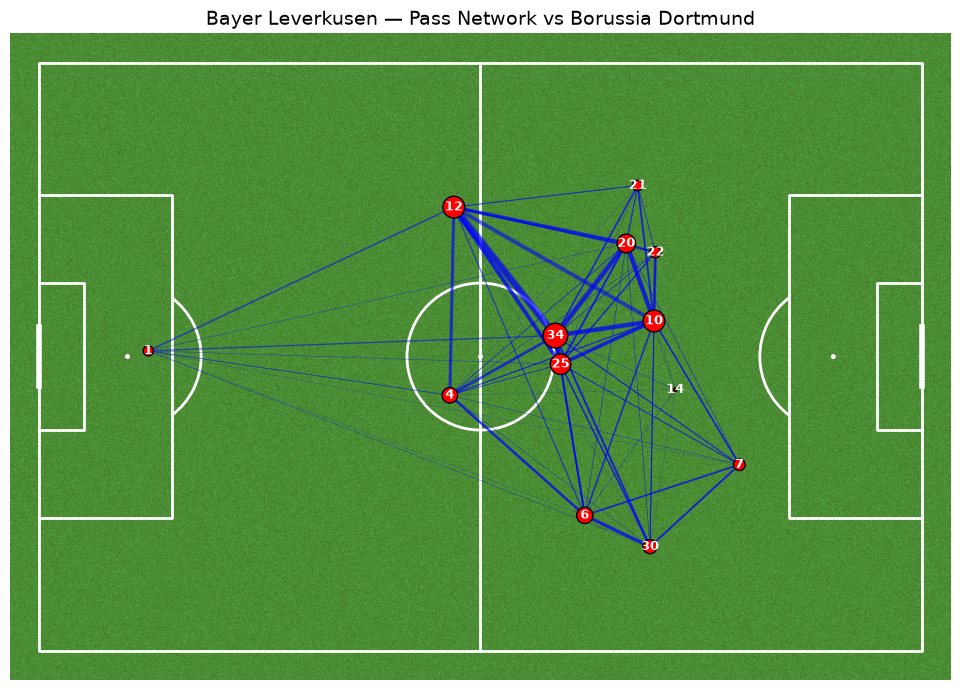

In [9]:
# --- Average positions and pass counts per player ---
avg_locations = completed_passes.groupby('player').agg({'x': 'mean', 'y': 'mean', 'id': 'count'})
avg_locations.columns = ['x', 'y', 'pass_count']

# --- Pass pairs (who passed to whom, how often) ---
pass_pairs = completed_passes.groupby(['player', 'pass_recipient']).size().reset_index(name='pass_count')
pass_pairs = pass_pairs.sort_values('pass_count', ascending=False)

# --- Merge in jersey numbers ---
number_map = lineups['Bayer Leverkusen'].set_index('player_name')['jersey_number']
avg_locations['jersey_number'] = avg_locations.index.map(number_map)

# --- Draw the pitch ---
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

# --- Draw lines between players, thickness = pass count ---
for _, row in pass_pairs.iterrows():
    passer = row['player']
    recipient = row['pass_recipient']
    count = row['pass_count']

    if passer in avg_locations.index and recipient in avg_locations.index:
        x1, y1 = avg_locations.loc[passer, ['x', 'y']]
        x2, y2 = avg_locations.loc[recipient, ['x', 'y']]
        ax.plot([x1, x2], [y1, y2], color='blue', linewidth=count/5, alpha=0.5, zorder=1)

# --- Draw player dots, sized by pass volume ---
pitch.scatter(avg_locations['x'], avg_locations['y'],
              s=avg_locations['pass_count']*3, color='red', edgecolors='black', ax=ax, zorder=2)

# --- Label each dot with jersey number ---
for player, row in avg_locations.iterrows():
    ax.annotate(str(int(row['jersey_number'])), xy=(row['x'], row['y']),
                ha='center', va='center', fontsize=9, color='white', weight='bold', zorder=3)

plt.title('Bayer Leverkusen — Pass Network vs Borussia Dortmund', fontsize=14)
plt.savefig('pass_network.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
## Summary

This stage visualizes match events spatially rather than statistically. 
The shot map shows where Bayer Leverkusen's shots originated in their 
match against Borussia Dortmund, highlighting goal locations. The pass 
network aggregates 608 completed passes into average player positions 
and connection strength between players, showing the team's passing 
structure and key distributors during the match.

SyntaxError: unterminated string literal (detected at line 4) (2924734802.py, line 4)